# The neural mesh-free Zakai filter — from scratch (the full model)

A self-contained build of the **complete** model: a physics-informed neural **operator** that amortizes the
exact nonlinear-filtering posterior (the **Zakai** equation), trained **mesh-free** (no state grid), that
**learns everything from data** — the latent drift $f$, the diffusion $g$, and the high-D observation map
$(C, d)$ — by online EM. The latent is 1-D but observed through a `D`-dim linear sensor (Duncker-style).

Only `torch` / `numpy` / `matplotlib`; everything defined inline; compared against the exact grid filter.
We finish with the model's **current failure mode** (posterior over-dispersion).

**Roadmap**
1. Filtering a low-D latent from high-D observations, with *unknown* dynamics and sensor.
2. The exact grid filter (oracle).
3. The operator (DeepONet log-density, continuous in time).
4. The mesh-free loss (SNIS + continuous-time Zakai residual).
5. EM: learn $f, g$ and the **Stiefel** sensor $C, d$ from the inferred latent path.
6. Train, visualize, discuss — including the over-dispersion failure mode.

## 1. The problem

$$dz_t = f(z_t)\,dt + \sigma\,dW_t \ (z\in\mathbb R^1),\qquad y_i = C z_i + d + \varepsilon_i \ (y\in\mathbb R^D,\ \varepsilon\sim\mathcal N(0,\rho^2 I)).$$

We know only the observation noise $\rho$. **Everything else — $f$, $\sigma$, and the sensor $C, d$ — is
learned.** The exact filtering object is the **Zakai equation** for the unnormalized density $\rho$,
$d\rho = \mathcal L^*\rho\,dt + \rho\,h\,dY_t$ with $\mathcal L^*\rho=-\partial_z(f\rho)+\tfrac12\partial_z^2(\sigma^2\rho)$:
Fokker–Planck **predict** between observations, **likelihood update** at each. A grid solves it exactly but
costs $O(N^d)$ in the latent dimension. We train a mesh-free operator for the E-step and learn the dynamics +
sensor in the M-step.

In [1]:
%matplotlib inline
import math
import torch
import torch.nn as nn
from torch.func import jvp
import matplotlib.pyplot as plt

torch.manual_seed(0)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", dev)

device: cuda


## 2. Data: 1-D double-well latent through a `D`-dim sensor (truth hidden from the model)

z: (80, 128)  y: (80, 128, 8)  (latent 1-D, obs 8-D)


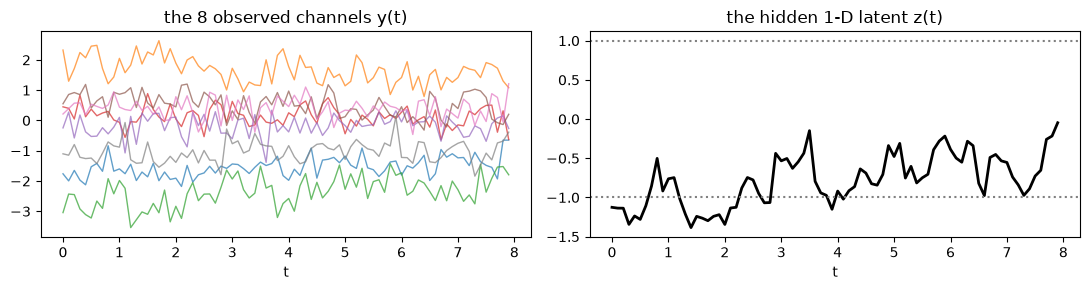

In [2]:
def make_dataset_highd(B, T, dt, obs_dim=8, a=1.0, sigma=0.6, noise_std=0.3,
                       c_scale=1.0, n_sub=5, seed=0):
    """1-D double-well latent z (T,B) + high-D linear obs y = C z + d + noise (T,B,D)."""
    g = torch.Generator().manual_seed(seed)
    sub = dt / n_sub
    z = torch.zeros(T, B); z[0] = torch.randn(B, generator=g)
    for t in range(1, T):
        zz = z[t - 1].clone()
        for _ in range(n_sub):
            zz = zz + a * (zz - zz**3) * sub + sigma * math.sqrt(sub) * torch.randn(B, generator=g)
        z[t] = zz
    C = c_scale * torch.randn(obs_dim, generator=g)
    d = torch.randn(obs_dim, generator=g)
    y = C * z[..., None] + d + noise_std * torch.randn(T, B, obs_dim, generator=g)
    return z, y, C, d                                       # z (T,B), y (T,B,D), C (D,), d (D,)

T, B, dt, obs_dim, n_val = 80, 128, 0.1, 8, 8             # B trajectories; the last n_val are held out for eval
a, sigma, noise_std, n_sub = 1.0, 0.6, 0.3, 5             # a, sigma, C, d are TRUTH -- the model learns them
# ONE dataset with ONE true sensor (C, d); train and val are a trajectory split, so they SHARE the sensor.
z_true, ys, C_true, d_true = make_dataset_highd(B, T, dt, obs_dim, a, sigma, noise_std, n_sub=n_sub)
ts = torch.arange(T) * dt
print("z:", tuple(z_true.shape), " y:", tuple(ys.shape), " (latent 1-D, obs %d-D)" % obs_dim)

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
for k in range(obs_dim): ax[0].plot(ts, ys[:, 0, k], lw=1, alpha=0.7)
ax[0].set_title(f"the {obs_dim} observed channels y(t)"); ax[0].set_xlabel("t")
ax[1].plot(ts, z_true[:, 0], "k-", lw=2); ax[1].axhline(1, ls=":", c="gray"); ax[1].axhline(-1, ls=":", c="gray")
ax[1].set_title("the hidden 1-D latent z(t)"); ax[1].set_xlabel("t")
plt.tight_layout(); plt.show()

## 3. The exact grid filter (oracle, for validation only)

In [3]:
def build_transition(f_grid, zg, dt_sub, sigma):
    diff = zg.unsqueeze(1) - (zg + f_grid * dt_sub).unsqueeze(0)
    return torch.softmax(-0.5 * diff**2 / (sigma**2 * dt_sub), dim=0)

def transition_power(K, n):
    Kn = K
    for _ in range(n - 1): Kn = K @ Kn
    return Kn

@torch.no_grad()
def exact_filter_highd(ys, zg, a, sigma, noise_std, dt, n_sub, C, d):
    K = transition_power(build_transition(a * (zg - zg**3), zg, dt / n_sub, sigma), n_sub)
    T, B = ys.shape[0], ys.shape[1]
    hz = C[None] * zg[:, None] + d[None]
    pi = torch.softmax(-0.5 * zg**2, 0)[None].expand(B, zg.numel()).clone()
    out = torch.zeros(T, B, zg.numel())
    for t in range(T):
        ll = -0.5 * ((ys[t][:, None, :] - hz[None])**2).sum(-1) / noise_std**2
        w = pi * (ll - ll.max(-1, keepdim=True).values).exp()
        pi = w / w.sum(-1, keepdim=True); out[t] = pi
        pi = pi @ K.t()
    return out

zmax, Nz = 3.0, 200
z_grid = torch.linspace(-zmax, zmax, Nz)
filt = exact_filter_highd(ys, z_grid, a, sigma, noise_std, dt, n_sub, C_true, d_true)
print("exact filter:", tuple(filt.shape))

exact filter: (80, 128, 200)


## 4. The operator: a DeepONet conditional log-density, continuous in time

$\ell_i(z, s) = \text{bias} + \sum_p b_p(c_i, s)\,\text{trunk}_p(z)$, $\pi_i(\cdot,s)=\text{softmax}_z\,\ell$.
A causal GRU encodes the **`D`-dim** observation stream into $c_i$; `trunk(z)` is a fixed basis in the **1-D**
query (mesh-free); the branch $b(c, s)$ takes the within-interval time $s\in[0,1]$ ($s{=}0$ post-update,
$s{=}1$ FP-predicted), so $\ell$ is differentiable in time by autodiff. The helpers return
$\partial_z\ell,\partial_z^2\ell$ and $\partial_s b$ via forward-mode `jvp`.

In [4]:
def mlp(sizes, act=nn.Tanh):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2: layers.append(act())
    return nn.Sequential(*layers)


class OperatorFilter(nn.Module):
    def __init__(self, data_size=1, gru_hidden=64, ctx_dim=64, p=48,
                 branch_hidden=128, trunk_hidden=64, trunk_layers=3):
        super().__init__()
        self.gru = nn.GRU(input_size=data_size + 1, hidden_size=gru_hidden)   # data_size = obs dim D
        self.to_ctx = nn.Linear(gru_hidden, ctx_dim)
        self.branch = mlp([ctx_dim + 1, branch_hidden, p])
        self.trunk = mlp([1] + [trunk_hidden] * trunk_layers + [p])
        self.bias = nn.Parameter(torch.zeros(()))

    def context(self, ys, mask):
        h, _ = self.gru(torch.cat([ys * mask, mask], dim=-1));  return self.to_ctx(h)

    def coeffs(self, ctx, s):
        ce = ctx.unsqueeze(2).expand(*ctx.shape[:2], s.numel(), ctx.shape[-1])
        se = s.reshape(1, 1, -1, 1).expand(*ctx.shape[:2], s.numel(), 1)
        return self.branch(torch.cat([ce, se], dim=-1))

    def coeffs_dtime(self, ctx, s):
        ce = ctx.unsqueeze(2).expand(*ctx.shape[:2], s.numel(), ctx.shape[-1])
        se = s.reshape(1, 1, -1, 1).expand(*ctx.shape[:2], s.numel(), 1)
        inp = torch.cat([ce, se], dim=-1)
        tan = torch.zeros_like(inp); tan[..., -1] = 1.0
        return jvp(self.branch, (inp,), (tan,))

    def trunk_zderivs(self, z):
        zin = z.reshape(-1, 1); e = torch.ones_like(zin)
        tau, dz = jvp(self.trunk, (zin,), (e,))
        _, d2z = jvp(lambda x: jvp(self.trunk, (x,), (e,))[1], (zin,), (e,))
        shp = (*z.shape, -1)
        return tau.reshape(shp), dz.reshape(shp), d2z.reshape(shp)

    def log_density(self, ctx, z, s=0.0):
        s_t = torch.as_tensor([s], dtype=z.dtype, device=z.device)
        b = self.coeffs(ctx, s_t)[:, :, 0]
        return torch.einsum("tbp,zp->tbz", b, self.trunk(z.unsqueeze(-1))) + self.bias

    def log_posterior(self, ys, mask, z):
        ell = self.log_density(self.context(ys, mask), z, s=0.0)
        return ell - torch.logsumexp(ell, dim=-1, keepdim=True)


model = OperatorFilter(data_size=obs_dim).to(dev)
print(sum(p.numel() for p in model.parameters()), "operator parameters")

44769 operator parameters


## 5. The mesh-free loss

Three SNIS terms — **IC**, **jump** (post-update $\approx$ normalize(predict$\times$likelihood)), and the
**residual** (log-space Fokker–Planck, all derivatives by autodiff). The likelihood
$\log\mathcal N(y; Cz+d, \rho^2 I)$ uses the **current learned** decoder, passed in as a `decode` closure; the
residual takes the **current learned** $f, g$.

In [5]:
def sample_collocation(center_z, mask, n_colloc, near_std=0.3, broad_std=1.6):
    """Draw 1-D z-samples from a proposal centered on the latent estimate center_z (T,B)."""
    T, B = center_z.shape
    dev = center_z.device
    obs = mask[..., 0]; center = center_z * obs
    near_sd = (near_std * obs + broad_std * (1 - obs)).unsqueeze(-1)
    Kn = n_colloc // 2; Kb = n_colloc - Kn
    near = center.unsqueeze(-1) + near_sd * torch.randn(T, B, Kn, device=dev)
    z = torch.cat([near, broad_std * torch.randn(T, B, Kb, device=dev)], -1)
    c2 = math.log(2.0) + 0.5 * math.log(2 * math.pi)
    lqn = -0.5 * ((z - center.unsqueeze(-1)) / near_sd)**2 - near_sd.log() - c2
    lqb = -0.5 * (z / broad_std)**2 - math.log(broad_std) - c2
    return z, torch.logaddexp(lqn, lqb)

def log_prior(z):
    return -0.5 * z**2

def zakai_loss(model, ys, mask, z_col, log_q, s_coll, decode, drift_fn, g, noise_std, dt):
    """decode(z)->(T,B,K,D), drift_fn(z)->(f,f'), g (latent diffusion): the CURRENT learned model."""
    T, B, K = z_col.shape
    ctx = model.context(ys, mask)
    tau = model.trunk(z_col.reshape(-1, 1)).reshape(T, B, K, -1)
    b_ends = model.coeffs(ctx, torch.tensor([0.0, 1.0], device=z_col.device))
    ell0 = torch.einsum("tbp,tbkp->tbk", b_ends[:, :, 0], tau) + model.bias
    loglik = -0.5 * ((ys.unsqueeze(2) - decode(z_col))**2).sum(-1) / noise_std**2   # high-D likelihood
    m = mask[..., 0]
    logZ0 = torch.logsumexp(ell0 - log_q, -1, keepdim=True) - math.log(K)
    logpi0 = ell0 - logZ0

    ellT_next = torch.einsum("tbp,tbkp->tbk", b_ends[:-1, :, 1], tau[1:]) + model.bias
    logW_pred = torch.log_softmax(ellT_next - log_q[1:], -1).detach()
    logW_tgt = torch.log_softmax(logW_pred + loglik[1:] * m[1:].unsqueeze(-1), -1)
    jump = -(logW_tgt.exp() * logpi0[1:]).sum(-1).mean()
    logW_ic = torch.log_softmax(log_prior(z_col[0]) + loglik[0] * m[0].unsqueeze(-1) - log_q[0], -1)
    ic = -(logW_ic.exp() * logpi0[0]).sum(-1).mean()

    b_s, ds_b = model.coeffs_dtime(ctx, s_coll)
    tau_s, dz_tau, d2z_tau = model.trunk_zderivs(z_col)
    dz_ell = torch.einsum("tbsp,tbkp->tbsk", b_s, dz_tau)
    d2z_ell = torch.einsum("tbsp,tbkp->tbsk", b_s, d2z_tau)
    ds_ell = torch.einsum("tbsp,tbkp->tbsk", ds_b, tau_s)
    f, df = drift_fn(z_col); f = f.unsqueeze(2); df = df.unsqueeze(2)
    rhs = -(df + f * dz_ell) + 0.5 * g**2 * (dz_ell**2 + d2z_ell)
    res = ((ds_ell / dt - rhs)**2).mean()
    return res, jump, ic

### How `jump` and `ic` connect to the Zakai equation

The Zakai SPDE for the unnormalized density $\rho_t(z)$ has two parts:
$$d\rho_t = \underbrace{\mathcal L^*\rho_t\,dt}_{\text{predict (Fokker–Planck)}} \;+\; \underbrace{\rho_t\,h(z)\cdot dY_t}_{\text{observation update}}.$$

The **predict** is what `residual` enforces. The **observation update** is what `jump` (and `ic` at $t{=}0$)
enforce — here is why. With **discrete, noisy** observations the continuous increment $h\,dY$ over one
inter-observation interval integrates into a single **likelihood multiplication**. Writing $\rho_i^-$ for the
predicted (FP-evolved) density just before observation $i$ and $\rho_i^+$ for the post-update density,
$$\rho_i^+(z)\;\propto\;\ell(y_i\mid z)\,\rho_i^-(z),\qquad \ell(y_i\mid z)=\mathcal N\!\big(y_i;\,h(z),\,\rho_{\text{obs}}^2 I\big),\quad h(z)=Cz+d.$$
So for discrete observations the Zakai equation **is** the predict→update recursion, and our three terms are
its three pieces:

| term | Zakai piece | enforces |
|---|---|---|
| `residual` | $\mathcal L^*\rho\,dt$ — predict | $\ell(z,s)$ obeys the log-FP equation in $s$ (autodiff) |
| **`jump`** | $\rho\,h\,dY$ — **observation update** | $\pi_{i+1}^+ = \text{normalize}\big(\ell(y_{i+1}\mid\cdot)\,\rho_i^-\big)$ |
| **`ic`** | initial condition $\rho(\cdot,0)$ | $\pi_0^+ = \text{normalize}\big(\ell(y_0\mid\cdot)\,\text{prior}\big)$ |

Concretely: **`jump` *is* the $\rho\,h\,dY$ observation term** of Zakai — the sensor $h(z)=Cz+d$ enters
through the likelihood, and "multiply by $\ell(y\mid z)$ and renormalize" is the discrete-observation form of
that stochastic integral. In the code, `logW_tgt = softmax(logW_pred + loglik)` is exactly $\rho_i^-$ (the
operator's *own* $s{=}1$ predicted density, `logW_pred`) times the likelihood (`loglik`), normalized; the
cross-entropy drives the operator's post-update $\pi_{i+1}^+$ to match it. **`ic` is that same update applied
to the SPDE's initial condition** $\rho(\cdot,0)=$ prior $\mathcal N(0,1)$ at $t{=}0$ (`logW_ic`). Because the
predict $\rho_i^-$ inside `jump` is the operator's own prediction, `residual` (predict) and `jump`/`ic`
(update) close the loop into the **full Zakai recursion** — with no exact filter anywhere in the loss. (The
$\rho_{\text{obs}}$ here is the observation noise; standard Zakai notation reuses $\rho$ for the density.)

## 5b. EM: learn $f$, $g$, and the **Stiefel** sensor $C, d$ from the inferred latent path

Gradients can't learn these (the marginal likelihood is nearly blind to $f$). Instead learn them from the
operator's **inferred latent path** — the strong *complete-data* channel:

- **drift** $f(z) = \mathbb E[\Delta z\mid z]/dt$ — regress on increments of the posterior-mean path.
- **diffusion** $g^2 = \mathrm{Var}[\Delta z\mid z]/dt$ — from the residual after a *trapezoidal* drift.
- **sensor** $C, d$ — fit $y \approx C\hat z + d$. A free $C$ runs away (a scale gauge: shrink $\hat z$,
  blow up $C$). The fix is a **Stiefel** decoder: constrain $C$ to **unit norm** and **fix the scale** $s$
  from the data. Then the M-step is the closed-form **orthogonal Procrustes** solution —
  $C = \text{unit}(\sum_t (y-\bar y)(\hat z-\bar{\hat z}))$ — and nothing can run away.

One more wrinkle: the latent has a **sign gauge** (the drift is odd), and if you fit $f$ on a latent inferred
through a *mis-aligned* sensor it gets stuck. So we use a **sensor-before-dynamics curriculum**: each M-step
fits $C$ first and only fits $f$ once $C$ has **stabilized** (its direction barely moved). By **default** we
initialize $C$ from a *random* unit direction — the honest test that the model truly **learns** the sensor
rather than having PCA hand it over. The first Procrustes M-step snaps $C$ onto the dominant covariance
direction of $y$ (which *is* $C_{\text{true}}$), and the curriculum holds the drift until it stabilizes. (Set
`pca_init=True` to warm-start from the top PCA direction of $y$ instead — it converges a bit faster.)

In [6]:
class DriftNet(nn.Module):
    """Learnable drift f_theta(z) -> (f, f') by autodiff; zero-init so f starts at 0."""
    def __init__(self, hidden=64, layers=3):
        super().__init__()
        self.net = mlp([1] + [hidden] * layers + [1])
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)
    def drift(self, z):
        zin = z.reshape(-1, 1)
        f, df = jvp(self.net, (zin,), (torch.ones_like(zin),))
        return f.reshape(z.shape), df.reshape(z.shape)


@torch.no_grad()
def posterior_mean_fixed(model, ys, mask, center, n_samples=256, near_std=0.3, broad_std=1.6):
    """MESH-FREE E[z_t | y_{0:t}] via DETERMINISTIC fixed-node importance sampling -- the grid-free M-step
    readout. The proposal nodes are drawn ONCE (fixed seed), reused every M-step and shared across t, so
    z_hat is a smooth *deterministic* function of the operator: the grid mean, but with data-following nodes
    (centered on the pseudo-inverse) instead of a uniform z-grid. Cost is O(K), independent of the latent
    dimension -> it scales to high-D latents where the O(N^d) grid can't.

    Determinism is the point: the increment-variance diffusion estimate g^2 = Var[dz]/dt amplifies any
    readout noise by 1/dt, so a *stochastic* readout (fresh samples each M-step) runs away; fixing the nodes
    removes that while keeping the MEAN. Returns (T,B)."""
    T, B = center.shape; dev = center.device
    gen = torch.Generator(device=dev).manual_seed(0)                     # fixed nodes -> deterministic readout
    obs = mask[..., 0]; c = center * obs
    near_sd = (near_std * obs + broad_std * (1 - obs)).unsqueeze(-1)
    Kn = n_samples // 2; Kb = n_samples - Kn
    eps_n = torch.randn(1, B, Kn, device=dev, generator=gen)             # shared across t (CRN) + fixed seed
    eps_b = torch.randn(1, B, Kb, device=dev, generator=gen)
    z = torch.cat([c.unsqueeze(-1) + near_sd * eps_n, (broad_std * eps_b).expand(T, B, Kb)], dim=-1)
    c2 = math.log(2.0) + 0.5 * math.log(2 * math.pi)
    lqn = -0.5 * ((z - c.unsqueeze(-1)) / near_sd)**2 - near_sd.log() - c2
    lqb = -0.5 * (z / broad_std)**2 - math.log(broad_std) - c2
    log_q = torch.logaddexp(lqn, lqb)
    ctx = model.context(ys, mask)
    b0 = model.coeffs(ctx, torch.zeros(1, device=dev))[:, :, 0]
    ell = torch.einsum("tbp,tbkp->tbk", b0, model.trunk(z.unsqueeze(-1))) + model.bias
    return (torch.softmax(ell - log_q, dim=-1) * z).sum(-1)              # SNIS-weighted mean (T,B)

@torch.no_grad()
def fit_sensor_stiefel(z_hat, ys, s_scale, C_cur):
    """Orthogonal Procrustes: C = unit direction of cross-cov(y, z_hat); scale s fixed. Returns
    (C_new, d_new, cstab) with cstab = 1 - |cos(C_new, C_cur)| (the curriculum gate signal)."""
    zf, yf = z_hat.reshape(-1), ys.reshape(-1, ys.shape[-1])
    M = ((yf - yf.mean(0)) * (zf - zf.mean())[:, None]).sum(0)
    C_new = M / M.norm().clamp_min(1e-8)
    cstab = 1.0 - abs(float(C_new @ C_cur))
    d_new = yf.mean(0) - s_scale * C_new * zf.mean()
    return C_new, d_new, cstab

def m_step(model, ys, mask, drift_net, dr_opt, dt, m_inner, reg_lambda, z_reg, hr,
           C_cur, d_cur, s_scale, c_stable_tol):
    center = ((ys - d_cur) * C_cur).sum(-1) / s_scale                    # pseudo-inverse latent estimate
    z_hat = posterior_mean_fixed(model, ys, mask, center)               # MESH-FREE deterministic readout (no z-grid)
    C_new, d_new, cstab = fit_sensor_stiefel(z_hat, ys, s_scale, C_cur)  # --- sensor first ---
    zc, zc_next = z_hat[:-1].reshape(-1), z_hat[1:].reshape(-1)
    dz = ((z_hat[1:] - z_hat[:-1]) / dt).reshape(-1)
    if cstab < c_stable_tol:                                            # --- gate: fit f only if C stable ---
        drift_net.requires_grad_(True)
        for _ in range(m_inner):
            dr_opt.zero_grad()
            f = drift_net.net(zc.unsqueeze(-1)).squeeze(-1)
            fr = drift_net.net(z_reg.unsqueeze(-1)).squeeze(-1)
            f_pp = (fr[2:] - 2 * fr[1:-1] + fr[:-2]) / hr**2
            (((f - dz)**2).mean() + reg_lambda * (f_pp**2).mean()).backward()
            dr_opt.step()
        drift_net.requires_grad_(False)
    with torch.no_grad():                                              # --- fit g (scalar) ---
        f_trap = 0.5 * (drift_net.net(zc.unsqueeze(-1)).squeeze(-1)
                        + drift_net.net(zc_next.unsqueeze(-1)).squeeze(-1))
        g = float(((dz - f_trap).pow(2).mean() * dt).sqrt().clamp(min=0.05))
    return g, C_new, d_new, cstab


## 6. Train (operator E-step + EM M-step for $f, g, C, d$)

Every step: an operator **E-step** (mesh-free Zakai loss with the current $f, g$ and decoder). Every
`m_every` steps after `warmup`: an **M-step** that re-fits the sensor (Procrustes) and — once it is stable —
the drift, plus the diffusion. The decoder and collocation center use the **current learned** $C, d$. A few
minutes on GPU; lower `STEPS` to sketch it.

In [7]:
zg = z_grid.to(dev)
y_dev = ys.to(dev)
y_tr, y_val = y_dev[:, n_val:], y_dev[:, :n_val]                 # trajectory split -- train & val SHARE C,d
z_val_true = z_true[:, :n_val]                                   # true held-out latent (for the results plot)
mask = torch.ones(T, y_tr.shape[1], 1, device=dev)
s_coll = torch.linspace(0, 1, 4, device=dev)
z_reg = torch.linspace(-2, 2, 80, device=dev); hr = float(z_reg[1] - z_reg[0])

# --- initialize the Stiefel sensor: fixed scale from the data + a unit direction (random, or PCA) ---
pca_init = False                                                  # honest test: learn C from a RANDOM direction
Yc = y_tr.reshape(-1, obs_dim); ybar = Yc.mean(0)
_, Sv, Vt = torch.linalg.svd(Yc - ybar, full_matrices=False)
s_scale = float(Sv[0] / math.sqrt(Yc.shape[0]))
C_cur = Vt[0].clone() if pca_init else torch.randn(obs_dim, device=dev)
C_cur = C_cur / C_cur.norm(); d_cur = ybar.clone()

drift_net = DriftNet().to(dev)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, 0.9998)
dr_opt = torch.optim.Adam(drift_net.parameters(), lr=2e-3)
g_cur = 1.0

STEPS, n_colloc, warmup, m_every, m_inner, reg_lambda, c_tol = 4000, 96, 1000, 1000, 300, 3e-4, 0.05
zeros_drift = lambda z: (torch.zeros_like(z), torch.zeros_like(z))
C_true_u = (C_true / C_true.norm()).to(dev)
for step in range(1, STEPS + 1):
    opt.zero_grad()
    decode = lambda z: s_scale * C_cur * z[..., None] + d_cur          # current learned sensor
    center = ((y_tr - d_cur) * C_cur).sum(-1) / s_scale                # latent estimate C^+ (y-d)/s
    z_col, log_q = sample_collocation(center, mask, n_colloc)
    drift_fn = zeros_drift if step <= warmup else drift_net.drift
    res, jump, ic = zakai_loss(model, y_tr, mask, z_col, log_q, s_coll, decode,
                               drift_fn, g_cur, noise_std, dt)
    (res + jump + ic).backward(); opt.step(); sched.step()
    if step > warmup and step % m_every == 0:
        g_cur, C_cur, d_cur, cstab = m_step(model, y_tr, mask, drift_net, dr_opt, dt,
                                            m_inner, reg_lambda, z_reg, hr, C_cur, d_cur, s_scale, c_tol)
    if step % 500 == 0:
        with torch.no_grad():
            f_l2 = (drift_net.drift(zg)[0] - a * (zg - zg**3))[zg.abs() <= 2].pow(2).mean().sqrt()
            ccos = abs(float(C_cur @ C_true_u))
        print(f"step {step:5d}  res={res.item():.3f}  jump={jump.item():.3f}  "
              f"drift L2={f_l2.item():.3f}  g={g_cur:.3f}  C cos={ccos:.3f}")

step   500  res=0.192  jump=0.344  drift L2=1.979  g=1.000  C cos=0.535


step  1000  res=0.194  jump=0.257  drift L2=1.979  g=1.000  C cos=0.535


step  1500  res=0.163  jump=0.218  drift L2=1.979  g=1.000  C cos=0.535


step  2000  res=0.140  jump=0.186  drift L2=1.979  g=0.690  C cos=0.999


step  2500  res=0.123  jump=0.049  drift L2=1.979  g=0.690  C cos=0.999


step  3000  res=0.120  jump=0.013  drift L2=0.460  g=0.824  C cos=1.000


step  3500  res=0.191  jump=0.271  drift L2=0.460  g=0.824  C cos=1.000


step  4000  res=0.171  jump=0.152  drift L2=0.747  g=0.818  C cos=1.000


## 7. Results & what you should see

Four panels: the **learned drift** vs the true cubic, the **sensor recovery** (learned unit-$C$ vs true,
sign-aligned), the **latent estimate** (mean $\pm2\sigma$) vs the truth, and a **posterior slice** vs exact.

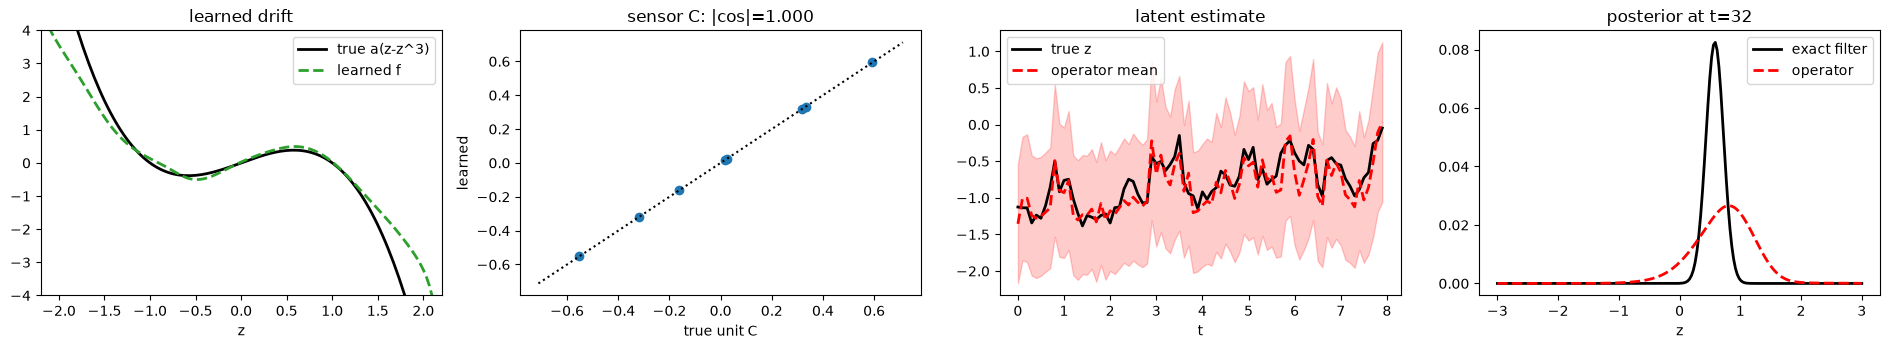

operator posterior std: 0.438   exact std: 0.137


In [8]:
mask_v = torch.ones(T, n_val, 1, device=dev)                      # y_val is the held-out split (same sensor)
with torch.no_grad():
    op = model.log_posterior(y_val, mask_v, zg).exp().cpu()
    f_learned = drift_net.drift(zg)[0].cpu()
filt_v = exact_filter_highd(y_val.cpu(), z_grid, a, sigma, noise_std, dt, n_sub,
                            (s_scale * C_cur).cpu(), d_cur.cpu())          # exact filter in the learned gauge
m_op = (op * z_grid).sum(-1); s_op = (op * z_grid**2).sum(-1).sub(m_op**2).clamp_min(0).sqrt()
m_ex = (filt_v * z_grid).sum(-1); zn = z_grid.numpy()

fig, ax = plt.subplots(1, 4, figsize=(19, 3.6))
ax[0].plot(zn, (a * (z_grid - z_grid**3)).numpy(), "k-", lw=2, label="true a(z-z^3)")
ax[0].plot(zn, f_learned.numpy(), "C2--", lw=2, label="learned f")
ax[0].set_ylim(-4, 4); ax[0].set_xlim(-2.2, 2.2); ax[0].set_title("learned drift"); ax[0].set_xlabel("z"); ax[0].legend()
cc = float(C_cur.cpu() @ C_true_u.cpu()); flip = 1.0 if cc >= 0 else -1.0
ax[1].plot(C_true_u.cpu().numpy(), (flip * C_cur.cpu()).numpy(), "o")
lim = float(C_true_u.abs().max()) * 1.2; ax[1].plot([-lim, lim], [-lim, lim], "k:")
ax[1].set_title(f"sensor C: |cos|={abs(cc):.3f}"); ax[1].set_xlabel("true unit C"); ax[1].set_ylabel("learned")
sgn = float(torch.sign((m_op * z_val_true).sum()))                # latent sign gauge -- align to true z for display
mo = sgn * m_op[:, 0]
ax[2].plot(ts, z_val_true[:, 0], "k-", lw=2, label="true z")
ax[2].plot(ts, mo, "r--", lw=2, label="operator mean")
ax[2].fill_between(ts, mo - 2 * s_op[:, 0], mo + 2 * s_op[:, 0], color="r", alpha=0.2)
ax[2].set_title("latent estimate"); ax[2].set_xlabel("t"); ax[2].legend()
t = 2 * T // 5
ax[3].plot(zn, filt_v[t, 0], "k-", lw=2, label="exact filter")
ax[3].plot(zn, op[t, 0], "r--", lw=2, label="operator")
ax[3].set_title(f"posterior at t={t}"); ax[3].set_xlabel("z"); ax[3].legend()
plt.tight_layout(); plt.show()

ex_std = (filt_v * z_grid**2).sum(-1).sub(m_ex**2).clamp_min(0).sqrt().mean()
print(f"operator posterior std: {s_op.mean():.3f}   exact std: {ex_std:.3f}")

## 8. What you should see — and the current failure mode

**What works — the full model, learned from data.** From a stream of `D`-dim observations alone the model
(i) **recovers the drift** $f_\theta$ tracing the double-well cubic; (ii) learns a constant diffusion
$g\approx0.6$; (iii) **recovers the sensor direction** ($|\cos|\to1$ between the learned unit-$C$ and the
truth) — even from a random init if you set `pca_init=False`; and (iv) produces a posterior whose **mean
tracks** the true latent and the exact-filter mean. That is amortized, mesh-free nonlinear filtering *and*
full system identification (dynamics + sensor) through a high-D linear sensor.

**The failure mode: posterior over-dispersion.** Compare the printed widths and the slice — the operator's
posterior is **~2–3× too wide**, even though its mean is right and the *target* it trains toward is correct.
Diagnosed:
- Not capacity — supervised against the exact filter the same architecture reaches KL $\approx2\times10^{-4}$.
- Not the proposal/target — the bootstrap target's width matches the exact filter; the operator fails to
  *match* it.
- It's the **continuous-time residual**: the post-update density is also the FP evolution's initial
  condition, and a sharp peak must diffuse *fast* right after the update; the smooth-in-$s$ branch can't
  represent that, so it broadens to keep the residual cheap. Any residual weight enforces this; removing it
  collapses the recursion.

A **representational/optimization limit of the time-in-branch parameterization**, not a wrong objective — and
it doesn't hurt the dynamics/sensor recovery, which use the mean. Open fixes: richer within-interval time
features ($\sqrt s$ / Fourier / sub-stepping), or decoupling the filtering head from the FP initial condition.

**Try next:** set `pca_init=False` (sensor learned from random); add an observation **gap** (zero `mask` on a
stretch) to see a **bimodal** posterior a Gaussian filter can't represent; or scale to a 2–3D latent (Lorenz),
where the mesh-free operator beats the $O(N^d)$ grid.